# Results: Order Buyout Prediction

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

sns.set_style("whitegrid")
DATA_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
RAW_DATA = Path("../data/raw/dataset_2025-03-01_2026-03-29_external.csv")

In [2]:
train_df = pd.read_parquet(DATA_DIR / "train.parquet")
test_df = pd.read_parquet(DATA_DIR / "test.parquet")
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]
X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]
with open(MODELS_DIR / "lgbm_model.pkl", "rb") as f:
    model = pickle.load(f)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Buyout rate: Train={y_train.mean():.1%}, Test={y_test.mean():.1%}")

Train: 13740, Test: 3435
Buyout rate: Train=82.2%, Test=82.2%


## Model Comparison

In [3]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
metrics = {
    "AUC-ROC": roc_auc_score(y_test, y_pred_proba),
    "F1": f1_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
}
baseline = {"AUC-ROC": 0.636, "F1": 0.671, "Precision": 0.874, "Recall": 0.545}
print(pd.DataFrame({"LightGBM": metrics, "LogReg": baseline}).round(3))

           LightGBM  LogReg
AUC-ROC       0.947   0.636
F1            0.951   0.671
Precision     0.977   0.874
Recall        0.926   0.545


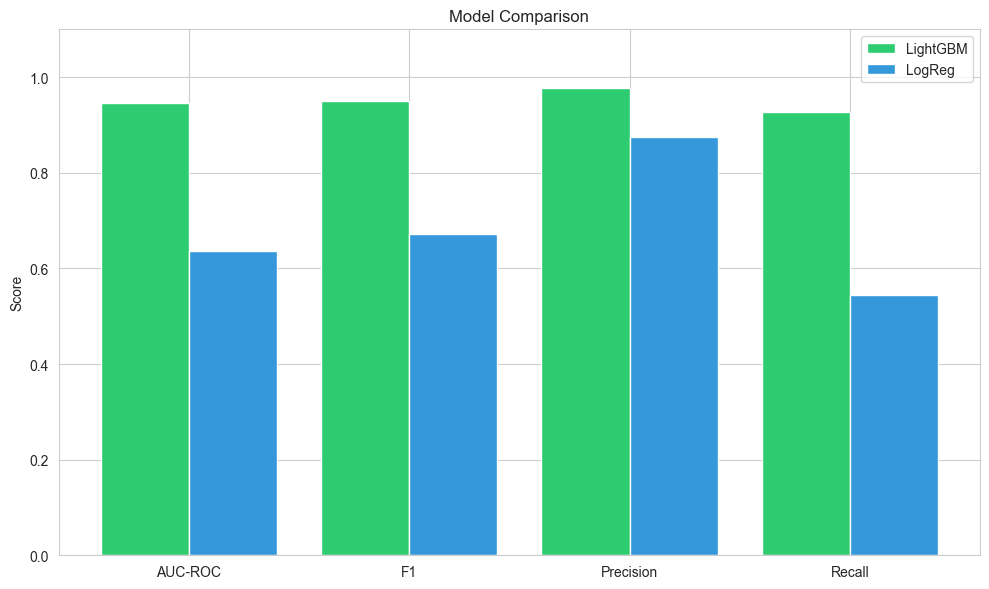

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
ax.bar(x - 0.2, list(metrics.values()), 0.4, label="LightGBM", color="#2ecc71")
ax.bar(x + 0.2, list(baseline.values()), 0.4, label="LogReg", color="#3498db")
ax.set_xticks(x)
ax.set_xticklabels(metrics.keys())
ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## Feature Importance

In [5]:
fi = pd.DataFrame(
    {"feature": X_train.columns, "importance": model.feature_importances_}
).sort_values("importance", ascending=False)
print(fi.head(20).to_string(index=False))

               feature  importance
           contact_LTV    0.470445
  contact_Число сделок    0.072486
            lead_price    0.029822
       weight_combined    0.021190
  lead_Трек-номер СДЭК    0.019847
     lead_Вес (грамм)*    0.019536
order_calculated_price    0.019132
    contact_created_at    0.018727
             lead_tags    0.018450
      contact_age_days    0.017085
       lead_created_at    0.016675
               sale_ts    0.016203
         contact_Город    0.015295
             lead_name    0.014629
         volume_approx    0.013802
         lead_age_days    0.013492
       contact_Код ПВЗ    0.012543
      lead_utm_content    0.012508
       contact_Телефон    0.012461
     lead_utm_campaign    0.011814


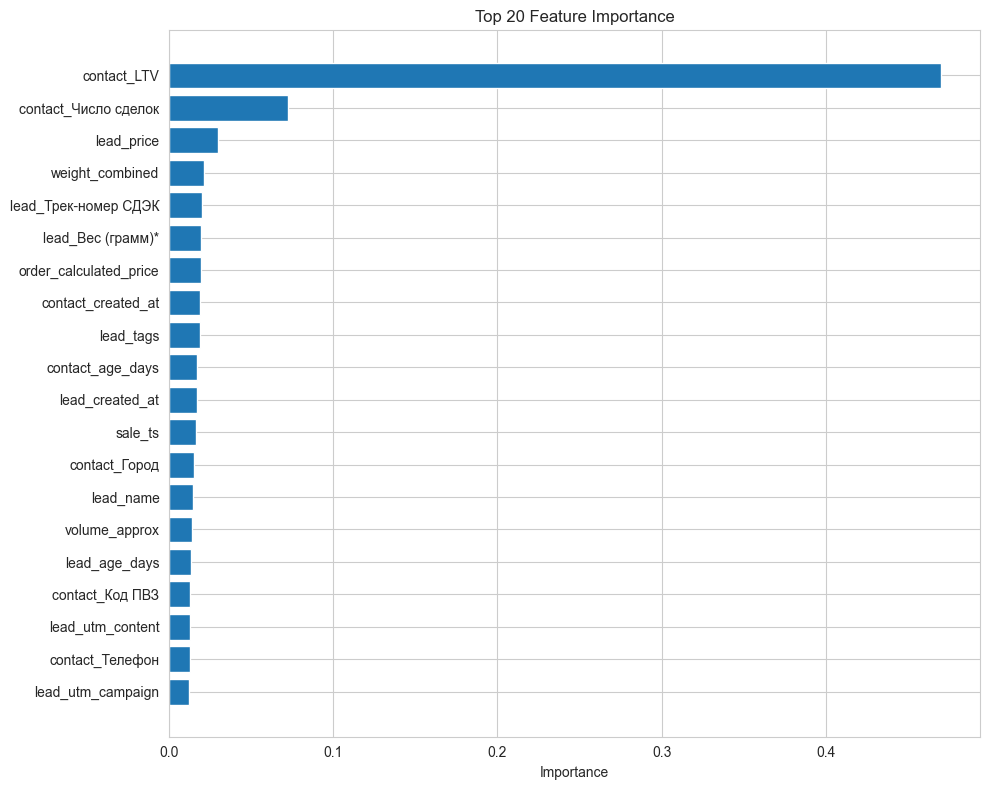

In [6]:
top = fi.head(20)
plt.figure(figsize=(10, 8))
plt.barh(range(20), top["importance"].values[::-1])
plt.yticks(range(20), top["feature"].values[::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importance")
plt.tight_layout()
plt.show()

## SHAP Analysis

In [7]:
explainer = shap.TreeExplainer(model)
sh = explainer.shap_values(X_test)
print(f"SHAP shape: {sh.shape}")

SHAP shape: (3435, 66, 2)


<Figure size 1200x1000 with 0 Axes>

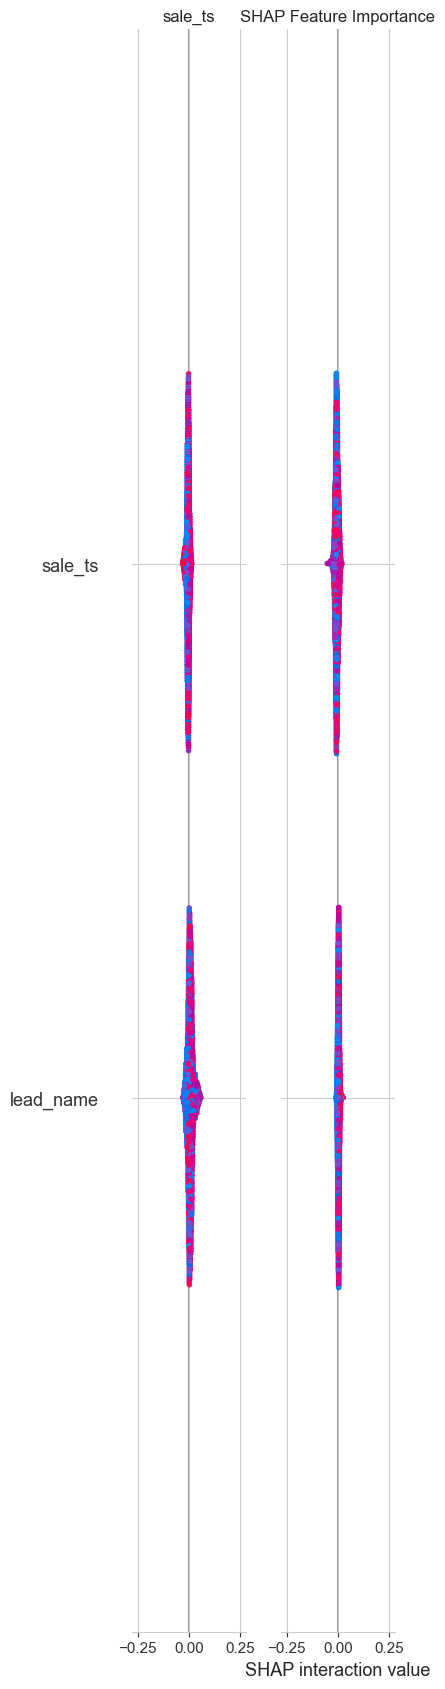

In [8]:
plt.figure(figsize=(12, 10))
shap.summary_plot(sh, X_test, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

<Figure size 1200x1000 with 0 Axes>

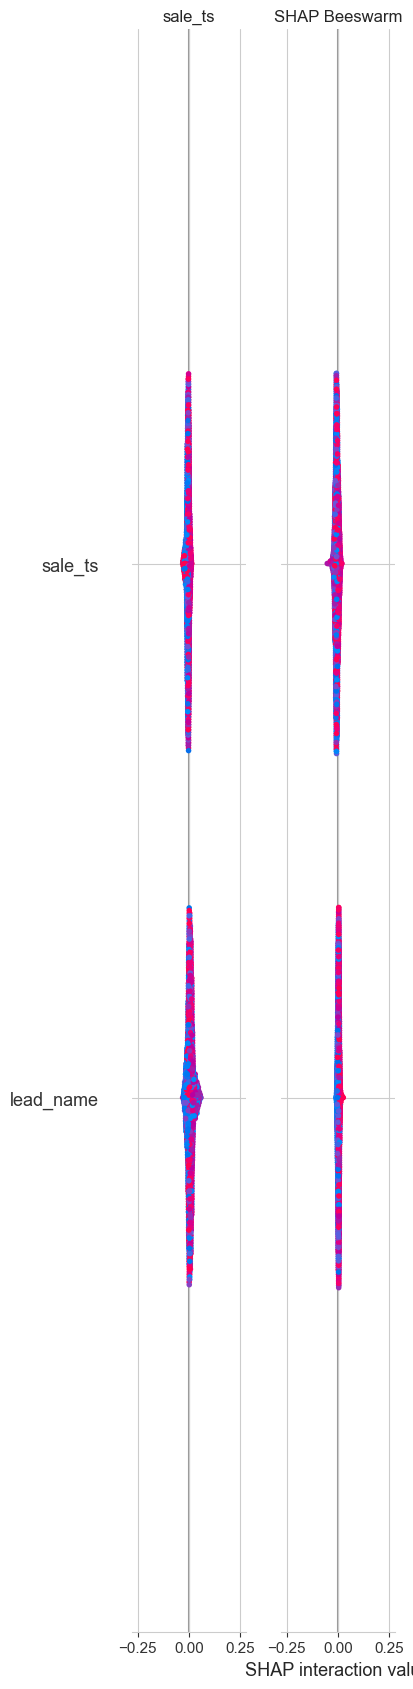

In [9]:
plt.figure(figsize=(12, 10))
shap.summary_plot(sh, X_test, show=False, max_display=20)
plt.title("SHAP Beeswarm")
plt.tight_layout()
plt.show()

## ROC Curve

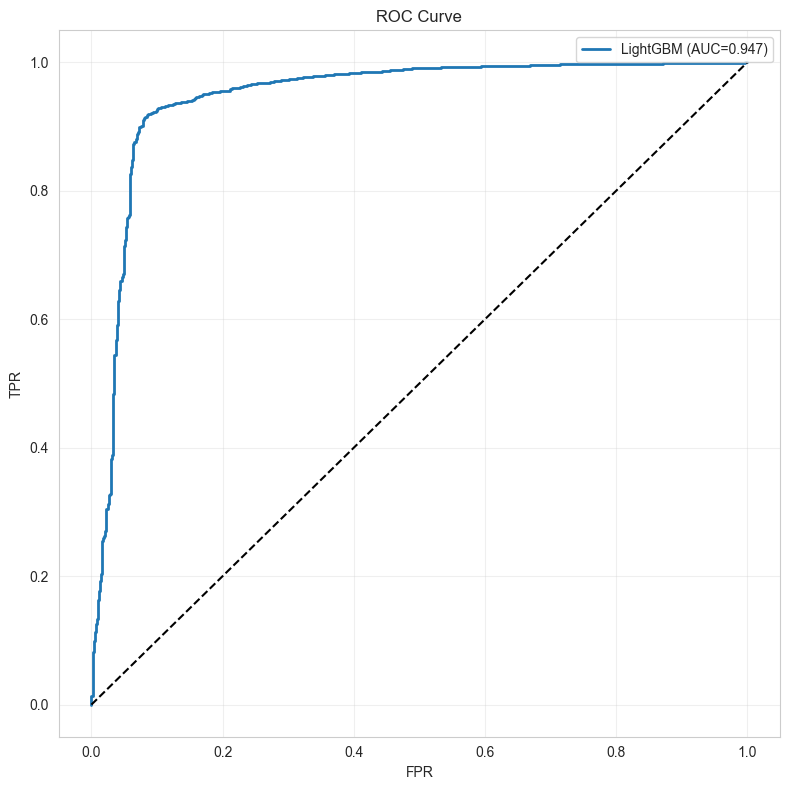

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label=f"LightGBM (AUC={auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Confusion Matrix

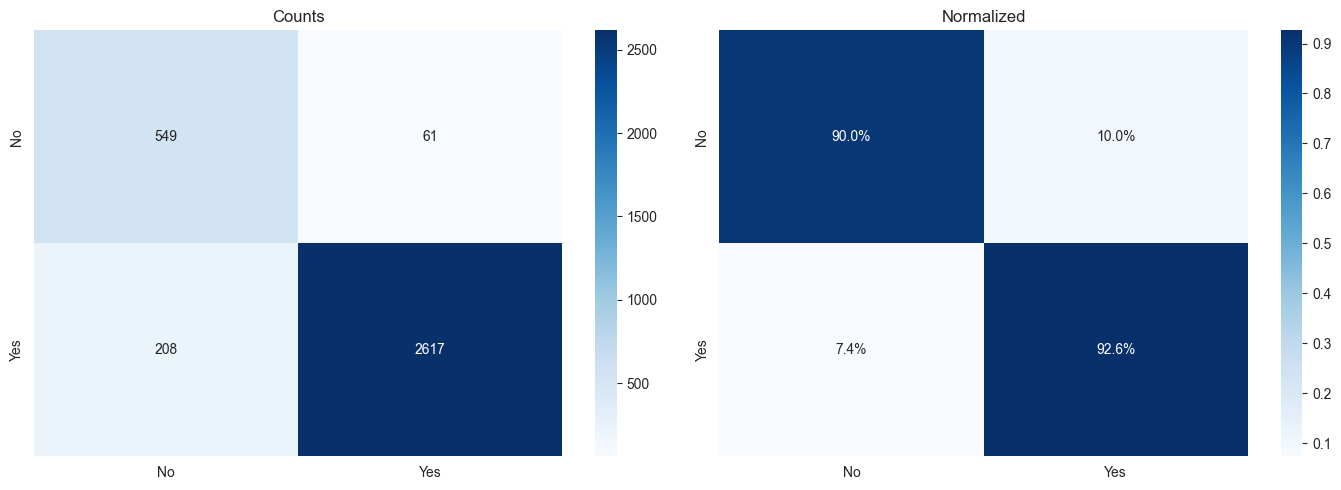

              precision    recall  f1-score   support

  Not Buyout       0.73      0.90      0.80       610
      Buyout       0.98      0.93      0.95      2825

    accuracy                           0.92      3435
   macro avg       0.85      0.91      0.88      3435
weighted avg       0.93      0.92      0.92      3435



In [11]:
cm = confusion_matrix(y_test, y_pred)
cm_n = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0],
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
ax[0].set_title("Counts")
sns.heatmap(
    cm_n,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    ax=ax[1],
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"],
)
ax[1].set_title("Normalized")
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred, target_names=["Not Buyout", "Buyout"]))

## Group Analysis

In [12]:
df_raw = pd.read_csv(RAW_DATA)
tr = df_raw.iloc[: len(y_test)].copy()
tr["y_true"] = y_test.values
tr["y_pred"] = y_pred
tr["y_proba"] = y_pred_proba

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6252\2163139232.py:1: DtypeWarning: Columns (0: lead_Оплата МОП, 1: lead_Счет оплачен, 2: lead_Название товара, 3: lead_Наименование получателя, 4: lead_ФИО, 5: lead_Адрес доставки, 6: contact_TelegramId_WZ, 7: lead_СМС-уведомления, 8: contact_TelegramUsername_WZ, 9: lead_Объявление, 10: lead_URL объявления, 11: lead_Поиск товаров GoSklad, 12: lead_Список товаров GoSklad, 13: lead_Колесо, 14: contact_Канал Callibri, 15: lead_ROISTAT_REFERRER, 16: lead_Категория и варианты выбора, 17: lead_Ссылка на документ, 18: lead_Выбранные товары, 19: contact_Ссылка на документ, 20: lead_Solo, 21: lead_YBAIP, 22: lead_from, 23: lead_Source phone, 24: lead_ИМ сдэк, 25: lead_Комментарий к отправлению, 26: lead_POLICY, 27: lead_LEADQUALIFYCATION, 28: lead_ROISTAT_POS, 29: lead_ROISTAT_FIELDS_ROISTAT, 30: lead_ROISTAT_URL, 31: lead_TEST-TAG, 32: lead_BANNER-SIZES, 33: lead_CTIME, 34: lead_BANNER-TEST-TAGS, 35: lead_BANNERS-VIDEOS, 36: lead_CONSTRUCTOR-RENDERED

In [13]:
city = (
    tr.groupby("contact_Город")
    .agg({"y_true": ["mean", "count"], "y_proba": "mean"})
    .round(3)
)
city.columns = ["actual", "count", "predicted"]
city = city[city["count"] >= 10].sort_values("count", ascending=False)
print(city.head(15))

                 actual  count  predicted
contact_Город                            
Москва            0.800    461      0.689
Санкт-Петербург   0.828    163      0.688
Новосибирск       0.792     48      0.651
Пермь             0.897     39      0.768
Краснодар         0.939     33      0.717
Самара            0.788     33      0.681
Иркутск           0.839     31      0.697
Ярославль         0.889     27      0.682
Владивосток       0.808     26      0.720
Казань            0.920     25      0.739
Нижний Новгород   1.000     25      0.771
Тюмень            0.800     25      0.694
Екатеринбург      0.920     25      0.733
Волгоград         0.800     25      0.636
Уфа               0.920     25      0.773


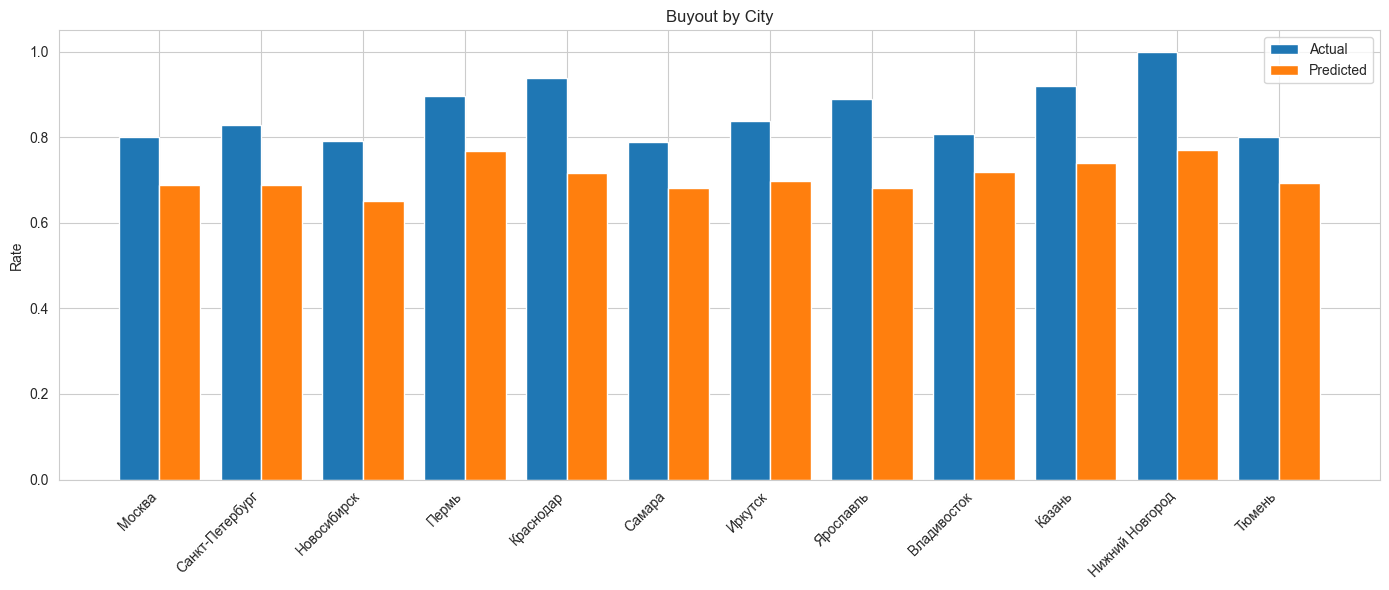

In [14]:
tc = city.head(12)
plt.figure(figsize=(14, 6))
x = np.arange(len(tc))
plt.bar(x - 0.2, tc["actual"], 0.4, label="Actual")
plt.bar(x + 0.2, tc["predicted"], 0.4, label="Predicted")
plt.xticks(x, tc.index, rotation=45, ha="right")
plt.ylabel("Rate")
plt.title("Buyout by City")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
utm = (
    tr.groupby("lead_utm_source")
    .agg({"y_true": ["mean", "count"], "y_proba": "mean"})
    .round(3)
)
utm.columns = ["actual", "count", "predicted"]
utm = utm[utm["count"] >= 5].sort_values("count", ascending=False)
print(utm.head(15))

                          actual  count  predicted
lead_utm_source                                   
ppc_ru_yandex_art_npz      0.814   2316      0.694
Youtube                    1.000     13      0.737
yandex                     0.615     13      0.542
sma_ru_vkontakte_art_npz   0.778      9      0.643


## Threshold Analysis

In [16]:
thresholds = np.arange(0.1, 0.95, 0.05)
tres = []
for t in thresholds:
    yp = (y_pred_proba >= t).astype(int)
    tres.append(
        {
            "threshold": t,
            "precision": precision_score(y_test, yp, zero_division=0),
            "recall": recall_score(y_test, yp, zero_division=0),
            "f1": f1_score(y_test, yp, zero_division=0),
        }
    )
tdf = pd.DataFrame(tres)
print(tdf.to_string(index=False))

 threshold  precision   recall       f1
      0.10   0.822416 1.000000 0.902556
      0.15   0.823753 0.999292 0.903071
      0.20   0.846339 0.998230 0.916031
      0.25   0.879224 0.994690 0.933400
      0.30   0.913657 0.985133 0.948050
      0.35   0.939124 0.972035 0.955297
      0.40   0.957401 0.954690 0.956044
      0.45   0.968910 0.937699 0.953049
      0.50   0.977222 0.926372 0.951118
      0.55   0.981003 0.913982 0.946307
      0.60   0.981644 0.908673 0.943750
      0.65   0.983197 0.890619 0.934621
      0.70   0.984460 0.829735 0.900499
      0.75   0.984802 0.688142 0.810169
      0.80   0.985537 0.506549 0.669161
      0.85   0.982262 0.313628 0.475449
      0.90   0.987069 0.162124 0.278504


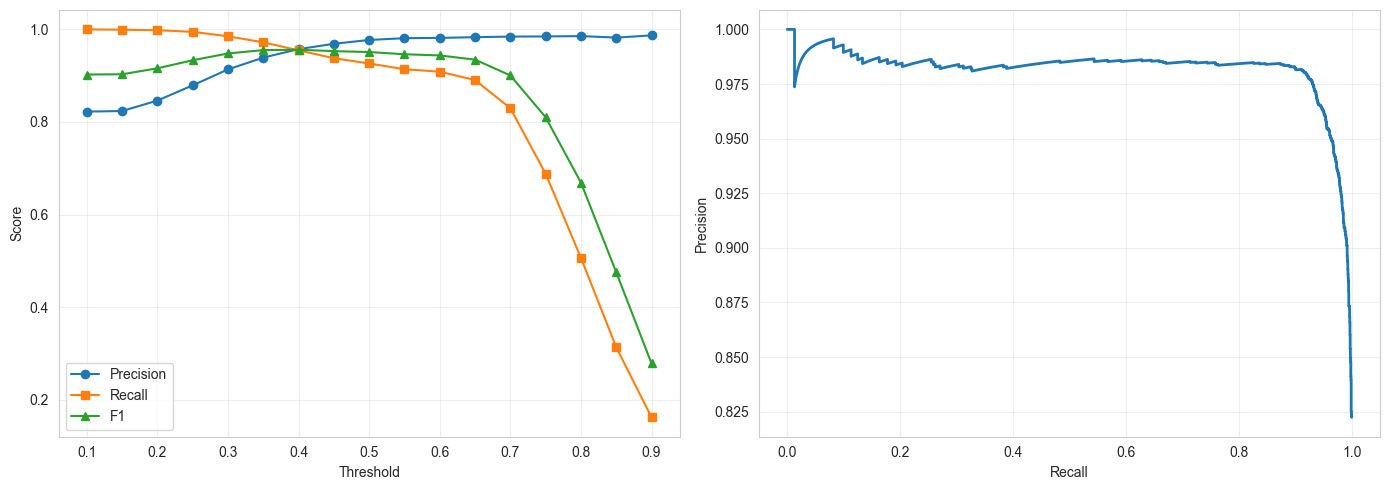

Best threshold: 0.40


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(tdf["threshold"], tdf["precision"], label="Precision", marker="o")
ax[0].plot(tdf["threshold"], tdf["recall"], label="Recall", marker="s")
ax[0].plot(tdf["threshold"], tdf["f1"], label="F1", marker="^")
ax[0].set_xlabel("Threshold")
ax[0].set_ylabel("Score")
ax[0].legend()
ax[0].grid(alpha=0.3)
p_curve, r_curve, _ = precision_recall_curve(y_test, y_pred_proba)
ax[1].plot(r_curve, p_curve, linewidth=2)
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
best_t = tdf.loc[tdf["f1"].idxmax(), "threshold"]
print(f"Best threshold: {best_t:.2f}")

## Error Analysis

In [18]:
fp = tr[(tr["y_true"] == 0) & (tr["y_pred"] == 1)]
fn = tr[(tr["y_true"] == 1) & (tr["y_pred"] == 0)]
print(f"FP: {len(fp)}, FN: {len(fn)}")

FP: 61, FN: 208


In [19]:
print("Top FP:")
print(
    fp.sort_values("y_proba", ascending=False)[
        ["contact_Город", "lead_price", "y_proba"]
    ].head(10)
)

Top FP:
                                          contact_Город  lead_price   y_proba
2413                                        Симферополь        7520  0.957647
1540                                             Москва        6525  0.930617
2595                                             Москва        7520  0.923985
1065                                             Москва        6170  0.920308
560                                   Каменск-Уральский        4605  0.915019
2534                                            Ступино       21550  0.911134
2157  397929, обл Воронежская, р-н Лискинский, с Лис...        6450  0.899708
866                                     Анжеро-Судженск        5610  0.893010
984                                     Санкт-Петербург       10800  0.886557
2538                               Глазов, удмуртс респ        3276  0.883384


In [20]:
print("Top FN:")
print(
    fn.sort_values("y_proba", ascending=True)[
        ["contact_Город", "lead_price", "y_proba"]
    ].head(10)
)

Top FN:
                                          contact_Город  lead_price   y_proba
3255                                             Москва       12990  0.130426
2039                                             Москва        3230  0.149601
2551                                             Москва        6277  0.154008
1792  390509, обл Рязанская, р-н Рязанский, с Льгово...        6380  0.190434
1331  обл Ленинградская, р-н Тосненский, гп Ульяновк...        5260  0.192499
1536                                             Москва        3240  0.201733
1898      край Краснодарский, г Новороссийск, с Мысхако       24270  0.203394
1103      238420 Багратионовск, Калининградская область        3458  0.210177
3414  655700, Респ Хакасия, р-н Аскизский, с Аскиз, ...        3470  0.221427
2852                                             Самара        7300  0.229382
